# Deadly Corridor multi-seed baseline analysis

This notebook analyzes the newest versioned held-out evaluation, keeping training seeds separate and pairing them by identical test seed.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

reports = sorted(Path('results/deadly_corridor_baseline').glob('*/report.json'))
if not reports:
    raise FileNotFoundError('No corridor reports found. Run python test_corridor.py first.')
report_path = reports[-1]
report = json.loads(report_path.read_text(encoding='utf-8'))
episodes = pd.DataFrame(report['episodes'])
print(f'Selected: {report_path.parent}')
print(f"Rows: {len(episodes)}; training seeds: {sorted(episodes.training_seed.unique())}")
episodes.head()

Selected: results\deadly_corridor_baseline\20260930T225326_730538Z
Rows: 300; training seeds: [np.int64(0), np.int64(1), np.int64(2)]


,training_seed,test_seed,episode,reward,raw_reward,decisions,player_dead,completed
0,0,10000,1,0.642593,64.259323,13,True,False
1,0,10001,2,0.292862,29.286240,11,True,False
2,0,10002,3,3.325263,332.526276,17,True,False
3,0,10003,4,1.120667,112.066711,13,True,False
4,0,10004,5,0.904906,90.490570,12,True,False


In [2]:
def bootstrap_ci(values, iterations=20_000, seed=340):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    means = rng.choice(values, (iterations, len(values)), replace=True).mean(axis=1)
    return np.quantile(means, [0.025, 0.975])

rows = []
for training_seed, frame in episodes.groupby('training_seed'):
    low, high = bootstrap_ci(frame.reward)
    rows.append({
        'training_seed': training_seed,
        'episodes': len(frame),
        'mean_reward': frame.reward.mean(),
        'reward_ci_low': low,
        'reward_ci_high': high,
        'median_reward': frame.reward.median(),
        'mean_decisions': frame.decisions.mean(),
        'death_rate': frame.player_dead.mean(),
        'completion_rate': frame.completed.mean(),
    })
summary = pd.DataFrame(rows)
summary.style.format({
    'mean_reward': '{:.3f}', 'reward_ci_low': '{:.3f}', 'reward_ci_high': '{:.3f}',
    'median_reward': '{:.3f}', 'mean_decisions': '{:.1f}',
    'death_rate': '{:.1%}', 'completion_rate': '{:.1%}',
})

,training_seed,episodes,mean_reward,reward_ci_low,reward_ci_high,median_reward,mean_decisions,death_rate,completion_rate
0,0,100,1.960,1.635,2.298,1.114,15.2,100.0%,0.0%
1,1,100,2.040,1.693,2.406,1.114,15.4,100.0%,0.0%
2,2,100,1.960,1.635,2.298,1.114,15.2,100.0%,0.0%


In [3]:
reward_matrix = episodes.pivot(index='test_seed', columns='training_seed', values='reward')
decision_matrix = episodes.pivot(index='test_seed', columns='training_seed', values='decisions')
print('Reward correlations across matched test seeds:')
display(reward_matrix.corr().round(4))
print('Seeds 0 and 2 identical rewards:', reward_matrix[0].equals(reward_matrix[2]))
print('Seeds 0 and 2 identical episode lengths:', decision_matrix[0].equals(decision_matrix[2]))

Reward correlations across matched test seeds:


training_seed,0,1,2
training_seed,,,
0,1.0000,0.9928,1.0000
1,0.9928,1.0000,0.9928
2,1.0000,0.9928,1.0000


Seeds 0 and 2 identical rewards: True
Seeds 0 and 2 identical episode lengths: True


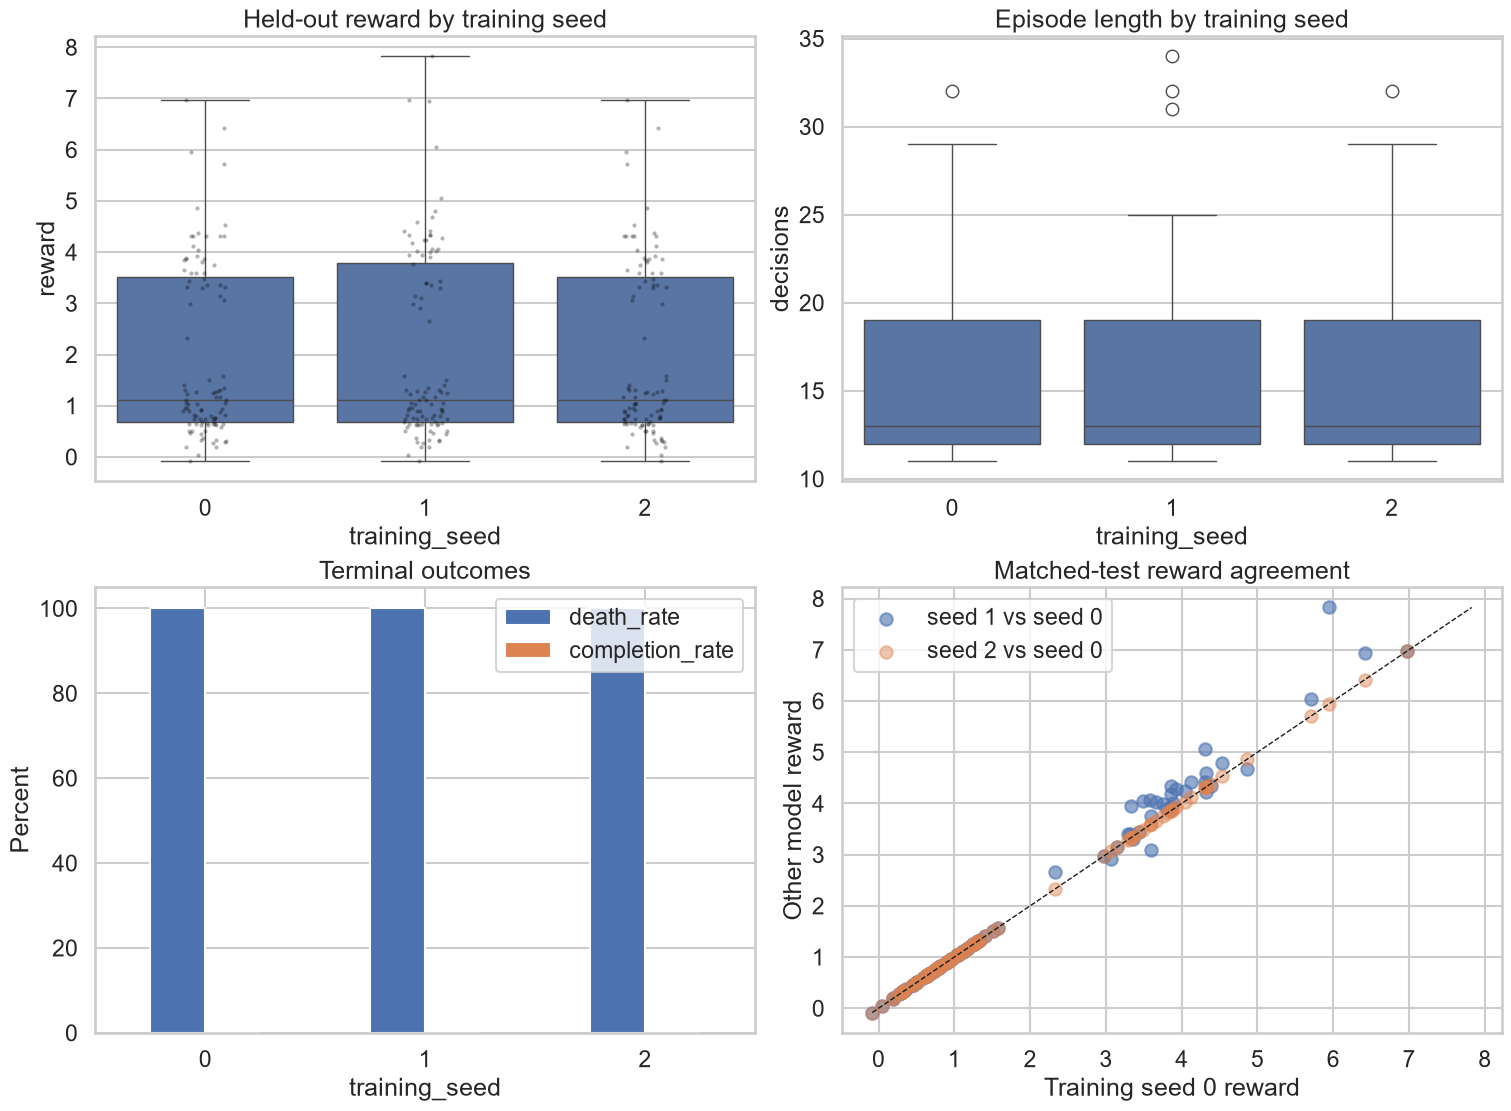

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
sns.boxplot(data=episodes, x='training_seed', y='reward', ax=axes[0, 0])
sns.stripplot(data=episodes, x='training_seed', y='reward', color='black', alpha=.3, size=3, ax=axes[0, 0])
axes[0, 0].set_title('Held-out reward by training seed')

sns.boxplot(data=episodes, x='training_seed', y='decisions', ax=axes[0, 1])
axes[0, 1].set_title('Episode length by training seed')

rate_table = summary.set_index('training_seed')[['death_rate', 'completion_rate']] * 100
rate_table.plot(kind='bar', ax=axes[1, 0], ylim=(0, 105), rot=0)
axes[1, 0].set(title='Terminal outcomes', ylabel='Percent')

axes[1, 1].scatter(reward_matrix[0], reward_matrix[1], alpha=.6, label='seed 1 vs seed 0')
axes[1, 1].scatter(reward_matrix[0], reward_matrix[2], alpha=.45, label='seed 2 vs seed 0')
limits = [reward_matrix.min().min(), reward_matrix.max().max()]
axes[1, 1].plot(limits, limits, 'k--', linewidth=1)
axes[1, 1].set(title='Matched-test reward agreement', xlabel='Training seed 0 reward', ylabel='Other model reward')
axes[1, 1].legend()
plt.show()

## Interpretation

Positive reward is not equivalent to solving Deadly Corridor. A 100% death rate and 0% completion rate show that the present reward permits a short combat strategy to score positively without traversing the corridor. This control must be repaired and retrained before attributing any improvement to temporal memory. The revised reward must then remain identical for PPO, FIFO memory, random-gated memory, and surprise-gated memory.